# Notebook: insilico 3G Assembly — 3 TUs per construct, with a shared TU across constructs


## What this notebook does

- Runs **Golden Gate → PCR → Gibson** for two 3-TU constructs (`C01`, `C02`) via `run_3g_batch_safe(...)`, then plots the assembly provenance with `build_histories_for_all_constructs(...)`.
- `C01` and `C02` deliberately **reuse the exact same TU1 and TU2** (same Promoter/RBS/Gene/Terminator/UNS_Context combination) and only differ in `TU3`. This is on purpose: it is a minimal, real reproduction of a bug report where building the *same* TU for two different constructs ("construct x and y") used to crash.

### The two bugs this example exercises (and that are now fixed)

1. **Identical TU across constructs used to crash on Windows.** `generate_recipe_assemblies()` re-simulated and re-wrote the *same* `*_report.zip` for every construct that reuses a TU. On Windows the OS can still hold the previous write's file handle for a moment, so the second `zip_path.unlink()` raised `PermissionError: [WinError 32]`. The fix (in `assembly_designer/plasmidio/assembly.py`) recognizes when a design resolves to the exact same part combination as an earlier one **within the same run** and reuses that result instead of re-simulating/re-writing it — which also matches how Golden Gate is supposed to behave (a given physical TU only needs to be built once, no matter how many final constructs reuse it).
2. **The history plot always drew the backbone at the median row, and used a fixed figure size.** With an odd number of TUs (like the 3 here), the backbone landed exactly on top of the middle TU's row. And because the figure size never grew with the number of TUs, labels started overlapping and became unreadable from 3 TUs onward. The fix (in `assembly_designer/plasmidio/history.py`) always places the backbone **below every other row**, and auto-sizes the figure from the actual number of rows/columns so labels stay legible as constructs grow (still overridable via `figsize=`).

Compare `Reports/History/C01_history.png` (or `C02_history.png`) here to the older plots in `../01 3G Gibson` or `../../05 3G Assembly` examples — the backbone now sits cleanly below TU1–TU3 instead of overlapping the middle TU.

---

## Inputs & expected layout

### 1) Excel design file (`gibson_designs_template.xlsx`)

**Sheets:**

- **`Constructs`** — `ConstructID`, `Name`, `Vector` (backbone stem), `MinOverlap`, `Circularize`, `Notes`
- **`TUs`** *(one row per TU per construct)* — `ConstructID`, `TU`, `Promoter`, `RBS`, `Gene`, `Terminator`, `UNS_Context`, `TU_Final_ID`
- **`PCR`** *(one row per role per construct)* — `ConstructID`, `Role`, `FwdPrimer`, `RevPrimer`, `Circular`, `MinAnneal`, `IncludeOverhangs`, `Notes`
- **`Assembly`** — `ConstructID`, `Order`, `FragmentRole`

### 2) Sequences & folders

Part sequences here are reused from the other Gibson/3G examples in this repo (`Ptuf`/`PH36`/`Psyn` promoters, `RBS_01`, `GFP_CD`/`RFP_CD`/`YFP_CD` genes, `TrrnB`/`TspyM`/`TthrM` terminators, `UNS1_UNS4_BB`/`UNS4_UNS5_BB`/`UNS5_UNS6_BB` context parts, `pEVmC(K)_AE` backbone) — no new sequences were invented for this example.

- `reports/Assembly/` → TU finals (GenBank) produced by Golden Gate
- `reports/Finals/` → final Gibson constructs (GenBank)
- `reports/History/` → PNGs of the provenance graphs


In [1]:
# ========================= 1) 3G batch runner + history (top-level re-exports) ===========================

from assembly_designer import (
    run_3g_batch_safe,          # batch wrapper: GG → PCR → Gibson
    BuildStatus,                # status dataclass returned per ConstructID
    AssemblyHistory,            # provenance graph (optional, for plotting)
    build_histories_for_all_constructs,  # convenience: one history per CID
)

import os
import pandas as pd

from Bio import SeqIO
from Bio.SeqRecord import SeqRecord

from assembly_designer.plasmidio import load_dna_file, remove_near_duplicate_features

import matplotlib.pyplot as plt   # used by AssemblyHistory.plot()
import networkx as nx             # used by AssemblyHistory.plot()

from pathlib import Path
from typing import Dict, Sequence


In [2]:
# ========================= 2) Configuration ===========================
BASE_DIR = Path.cwd()

# Where Golden Gate report ZIPs, TU finals, and Gibson finals will be written.
REPORTS_DIR = BASE_DIR / "reports"
ASSEMBLY_DIR = REPORTS_DIR / "Assembly"  # TU finals (GenBank) end up here

# Exact order of categories per TU design (and their folders)
category_order: Sequence[str] = ["Promoter", "RBS", "Gene", "Terminator", "UNS_Context"]

folder_paths = [
    BASE_DIR / "01_Promoter_Parts",
    BASE_DIR / "02_RBS_Parts",
    BASE_DIR / "03_Gene_of_Interest_Parts",
    BASE_DIR / "04_Terminator_Parts",
    BASE_DIR / "05_UNS_Context_Parts",
]
category_dirs: Dict[str, Path] = dict(zip(category_order, folder_paths))

# Find and load the backbone (prefer .dna if available)
vec_dir = BASE_DIR / "06_Gibson_Backbone_Parts"
vec_files = [p for p in vec_dir.iterdir() if p.suffix.lower() in {".dna", ".gb", ".gbk", ".genbank"}]
if not vec_files:
    raise FileNotFoundError(f"No vector files in {vec_dir}")

vector_path = next((p for p in vec_files if p.suffix.lower() == ".dna"), vec_files[0])
vector_rec: SeqRecord = load_dna_file(vector_path)
vector_rec.id = vector_rec.name = vector_path.stem
vector_rec.annotations.setdefault("molecule_type", "DNA")
print("Vector:", vector_rec.id)


Vector: pEVmC(K)_AE


In [3]:
# ========================= 3) Load Excel sheets =======================
xlsx_path = "gibson_designs_template.xlsx"
xl = pd.read_excel(xlsx_path, sheet_name=None)

constructs_df = xl.get("Constructs", pd.DataFrame()).copy()
pcr_df        = xl["PCR"].copy()
assembly_df   = xl["Assembly"].copy()
tus_df        = xl.get("TUs", pd.DataFrame()).copy()

display(tus_df)

# The Golden Gate "designs": one dict per TU (columns must match category_order).
# Note that TU1 and TU2 of C02 resolve to the exact same part combination as
# TU1/TU2 of C01 — this is the identical-TU scenario the fix in assembly.py handles.
designs = tus_df.to_dict("records")


,ConstructID,TU,Promoter,RBS,Gene,Terminator,UNS_Context,TU_Final_ID
0,C01,TU1,Ptuf,RBS_01,GFP_CD,TrrnB,UNS1_UNS4_BB,Ptuf_RBS_01_GFP_CD_TrrnB_UNS1_UNS4_BB
1,C01,TU2,Ptuf,RBS_01,RFP_CD,TspyM,UNS4_UNS5_BB,Ptuf_RBS_01_RFP_CD_TspyM_UNS4_UNS5_BB
2,C01,TU3,PH36,RBS_01,YFP_CD,TthrM,UNS5_UNS6_BB,PH36_RBS_01_YFP_CD_TthrM_UNS5_UNS6_BB
3,C02,TU1,Ptuf,RBS_01,GFP_CD,TrrnB,UNS1_UNS4_BB,Ptuf_RBS_01_GFP_CD_TrrnB_UNS1_UNS4_BB
4,C02,TU2,Ptuf,RBS_01,RFP_CD,TspyM,UNS4_UNS5_BB,Ptuf_RBS_01_RFP_CD_TspyM_UNS4_UNS5_BB
5,C02,TU3,Psyn,RBS_01,YFP_CD,TthrM,UNS5_UNS6_BB,Psyn_RBS_01_YFP_CD_TthrM_UNS5_UNS6_BB


In [4]:
def template_lookup(cid, role):
    """Explicit lookup: TUs sheet → TU_Final_ID → GenBank file."""
    role_s = str(role).strip()
    if role_s.lower() == "backbone":
        return vector_rec

    row = tus_df[(tus_df["ConstructID"].astype(str) == str(cid)) &
                 (tus_df["TU"].astype(str).str.upper() == str(role_s).upper())]
    if row.empty:
        raise ValueError(f"No TU row for ({cid}, {role})")

    tu_final_id = str(row.iloc[0].get("TU_Final_ID", "")).strip()
    if not tu_final_id:
        raise ValueError(f"No TU_Final_ID for ({cid}, {role})")

    final_path = Path(REPORTS_DIR) / "Assembly" / f"{tu_final_id}.gb"
    if not final_path.exists():
        raise FileNotFoundError(f"TU final not found: {final_path}")

    rec = SeqIO.read(str(final_path), "genbank")
    rec.id = rec.name = final_path.stem
    rec.annotations.setdefault("molecule_type", "DNA")
    return rec


In [5]:
# 1) Run the batch (GG → PCR → Gibson).
# C01 and C02 both request TU1/TU2 with identical parts: Golden Gate now
# builds that TU once and reuses it for both constructs instead of crashing.
batch = run_3g_batch_safe(
    category_dirs=category_dirs,
    designs=designs,
    category_order=category_order,
    reports_dir=REPORTS_DIR,
    pcr_plan_df=pcr_df,
    assembly_df=assembly_df,
    tus_df=tus_df,
    constructs_df=constructs_df,
    template_lookup=template_lookup,
)


In [6]:
# delete near-duplicate features in all extracted GenBank files
# (optional, but recommended if your parts have overlapping annotations)
assembly_folder = Path("reports") / "Finals"

for file_name in os.listdir(assembly_folder):
    if file_name.endswith(".gb") or file_name.endswith(".gbk"):
        file_path = os.path.join(assembly_folder, file_name)
        remove_near_duplicate_features(file_path, tolerance=3)  # Tolerance of ±3 bases


✅ Cleaned file saved: reports\Finals\C01_final.gb
✅ Cleaned file saved: reports\Finals\C02_final.gb


In [7]:
# 2) Unpack artifacts you need for the history
status_df   = batch.status_df
products    = batch.products         # dict[(cid, role)] -> PCR product (SeqRecord)
pcr_results = batch.pcr_results      # dict[(cid, role)] -> PCRResult (optional)
finals      = batch.finals           # dict[cid] -> final Gibson SeqRecord

display(status_df)


,gg_ok,gg_msg,pcr_ok,pcr_msg,gibson_ok,gibson_msg,final_path,final_bp
cid,,,,,,,,
C01,True,,True,,True,,C:\Users\tim\repos\assembly_designer - GitHub\...,9015
C02,True,,True,,True,,C:\Users\tim\repos\assembly_designer - GitHub\...,8960


C:\Users\tim\repos\assembly_designer - GitHub\assembly_designer\plasmidio\history.py:926: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


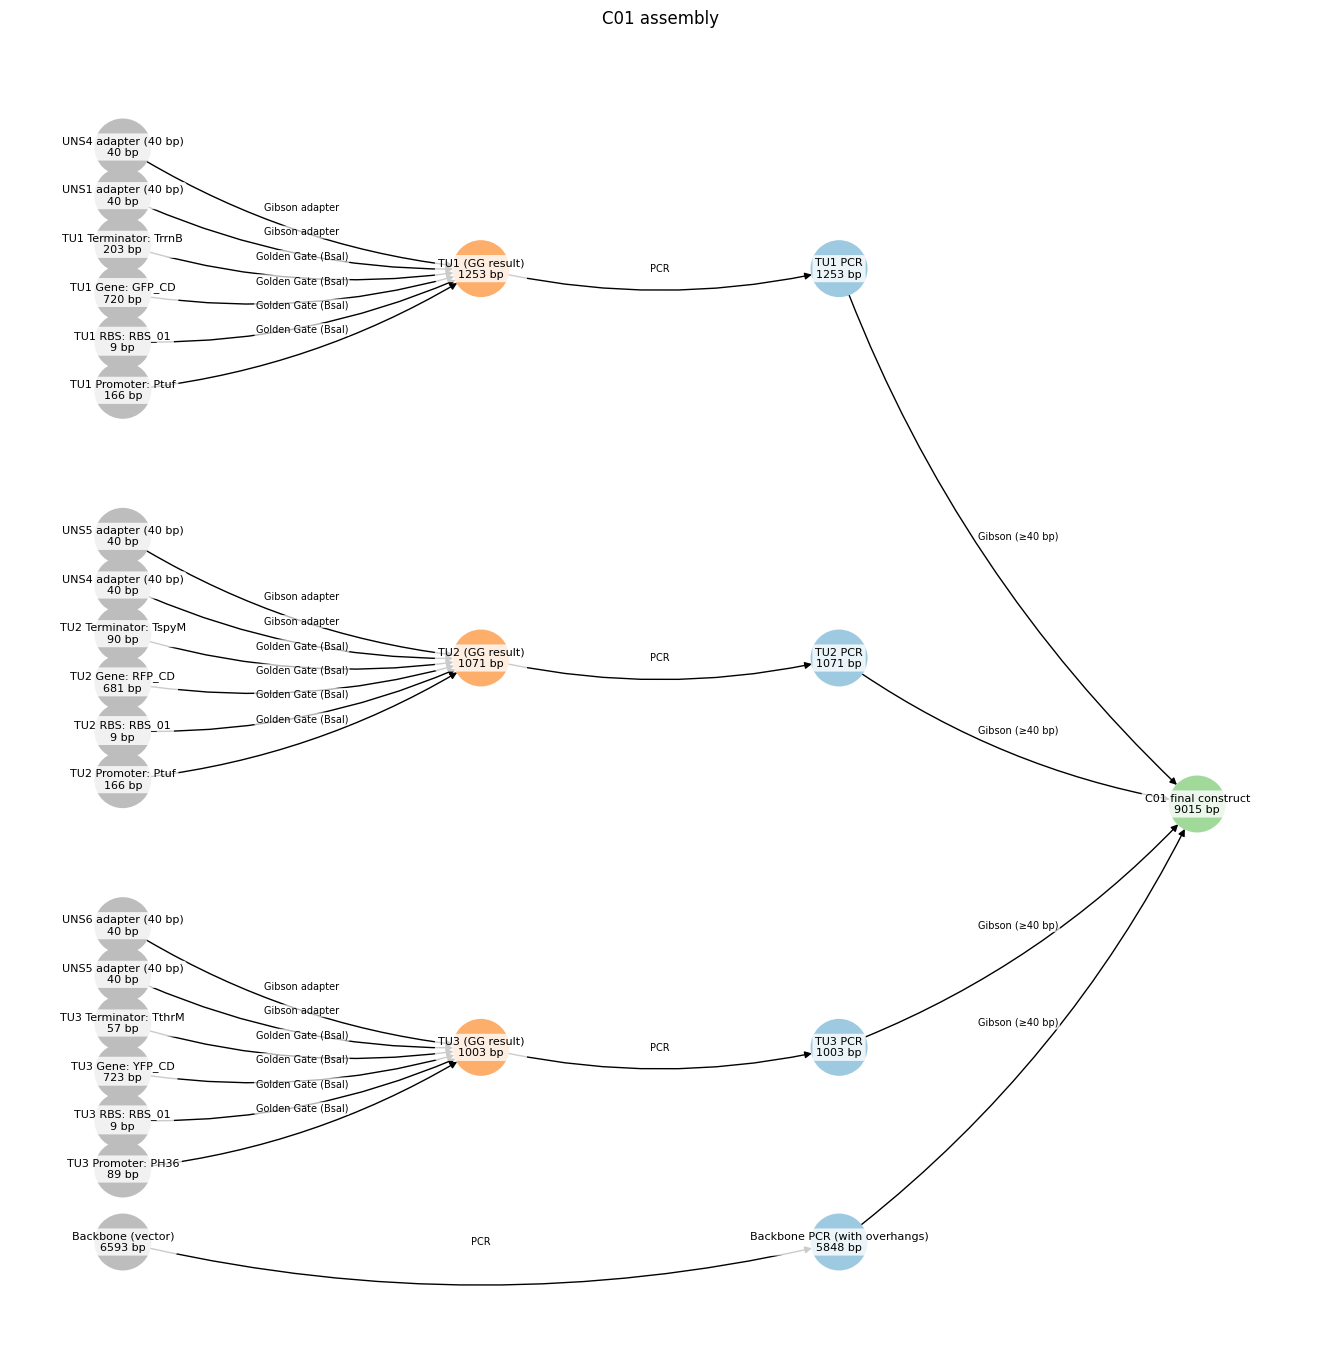

C:\Users\tim\repos\assembly_designer - GitHub\assembly_designer\plasmidio\history.py:926: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


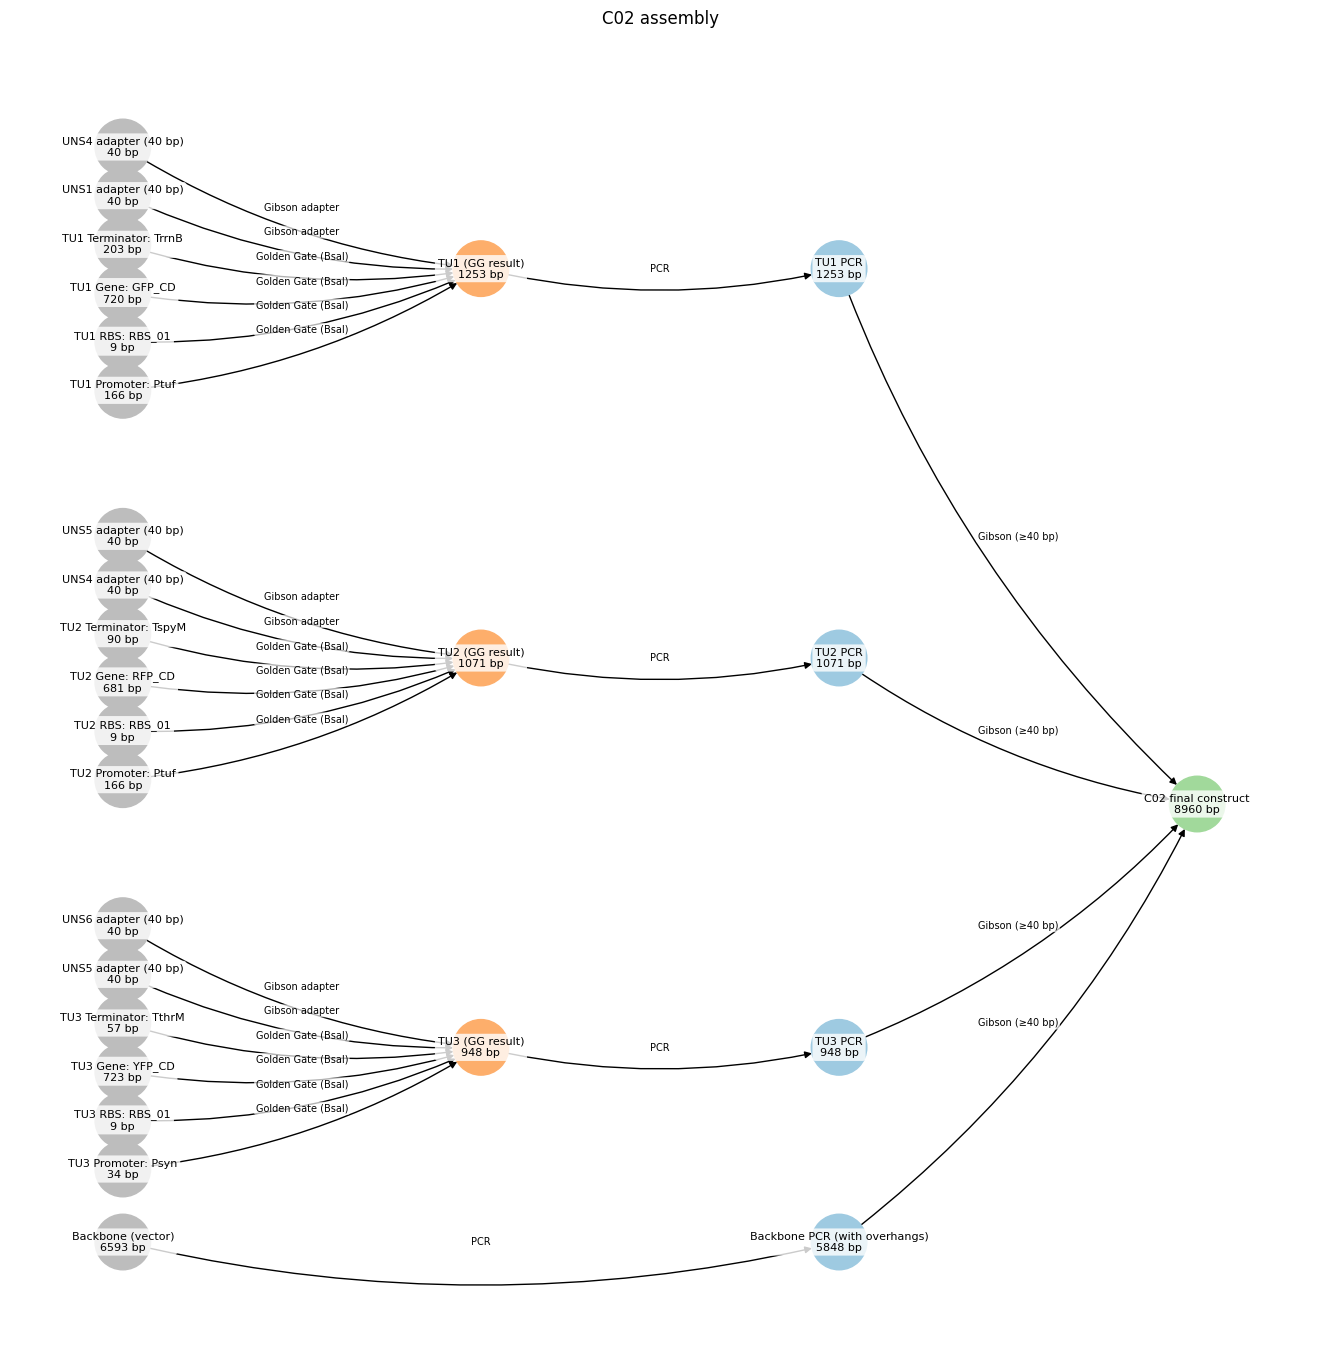

In [8]:
# 3) Build + plot histories (and save PNGs).
# figsize is left at its default (None): AssemblyHistory.plot() now sizes the
# figure from the number of rows/columns instead of squeezing everything into
# a fixed box, and always draws the backbone below the TU rows.
histories = build_histories_for_all_constructs(
    constructs_df=constructs_df,
    assembly_df=assembly_df,
    tus_df=tus_df,
    vector_rec=vector_rec,
    products=products,
    pcr_results=pcr_results,
    finals=finals,
    plot=True,
    save_png_dir=Path("reports/History"),
)
